In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.io import loadmat
import random
import pandas as pd

import ERS_functions as ERS

%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
'''
(c) TU Delft
This script will analyse all the accelerograms (x,y,z) direction and
construct their ERS based on a numerical calculation. The mean of the
horizontal and vertical acting accelerograms will be calculated as well
and will be saved to a .mat file. Furthermore, the signals will be
made RFEM ready and placed in a folder. 

!!!!!!!!!!!!!!!!!!!!!!
Please note that every time
this file runs, it will add the signal data to the existing files in
"Signals", therefore make sure that if you re-run this file you
delete those files.

At some locations you will find '<---- fill in equation', please fill in the
appropriate equation here to continue.
'''

# generate the random number to choose specific files
files = random.sample(range(8),5)
print('Chosen files are: ' + str(files))

## importing acclerograms and looping over them to create the ERS

A = 5
B = 8
C = 2
D = 9
E = 6
F = 1
G = 5
# Determine scaling value:
gamma = 1.4 #Based on Eurocode 8 for class IV                               # <------ fill in equation here
a_g = (0.35+C/100)  
PGA = gamma * a_g                              # <------ fill in equation here


# initialising loop
N = len(files)
SA_el_hor = np.zeros((201,2*N))
SA_el_ver = np.zeros((201,N))
ag_all = [None] * (3*N)
NPTS_all = np.zeros((N,))
Dt_all = np.zeros((N,))

## loops for reading files and decomposing in principal directions
jj = 0
for ifile in files:
    NPTS, Dt, ag_time = ERS.fnc_read_induced_signals(ifile)
    for ii in range(3):
        ag_all[3*jj+ii] = ag_time[ii]
    NPTS_all[jj] = NPTS
    Dt_all[jj] = Dt
    jj += 1
    
for iN in range(N):
    # get the file locations
    hor1 = 3*iN + 1 
    hor2 = 3*iN + 2
    ver = 3*iN + 3

    ag_1, ag_2 = ERS.fnc_calc_covariance(ag_all[hor1-1], ag_all[hor2-1], ag_all[ver-1], Dt_all[iN])
    ag_all[hor1-1] = ag_1 # store 1st principal hor. dir.
    ag_all[hor2-1] = ag_2 # store 2nd principal hor. dir.    

    
# loop for calculation response spectra and saving decomposed signals such that ZeusNL is able to use them

PGA_init = [None] * (3*N) 

for iN in range(1, N+1):
    # get the file locations
    hor1 = 3*(iN-1) + 0  
    hor2 = 3*(iN-1) + 1
    ver = 3*(iN-1) + 2
    for ifile in [hor1, hor2, ver]:
        # read the signal
        ag_time = ag_all[ifile]
        NPTS = NPTS_all[iN-1]
        Dt = Dt_all[iN-1]
        
        # In order to scale down the time history signal to a predifined PGA we 
        # have to:
        #   1) Find the initial PGA (absolute value) of the signal named after 
        #      "PGA_init" below; 
        #   2) We scale the signal such that PGA = PGA_max in case of the first and second principal hor. dir. 
        #      and the vertical one is scaled with the same ratio as the first principal hor. dir.
                
        PGA_init[ifile] = np.max(np.abs(ag_time))/(100*9.81)    #  (data is in cm/s^2) - convert to g
        
        if ifile != ver: 
            ag_time = PGA/PGA_init[ifile] * ag_time / (100*9.81) 
        else:
            ag_time = PGA/PGA_init[hor1] * ag_time / (100*9.81)  
        
        ## calculate the elastic response spectrum
        xi = 0.04+C/1000                            # <------ fill in equation here
        
        SA_el, Fel  =  ERS.fnc_Elastic_Response_Spectrum(ag_time, Dt, NPTS, xi)

        # determine in which array it should be stored
        if ifile == hor1:
            loc = 2*(iN-1) + 1
            name = 'hor1'
            SA_el_hor[:, loc-1] = SA_el
            ag_hor1 = ag_time * 9.81 # convert back to m/s2 for RFEM
        elif ifile == hor2:
            loc = 2*(iN-1) + 2
            name = 'hor2'
            SA_el_hor[:, loc-1] = SA_el
            ag_hor2 = ag_time * 9.81 # convert back to m/s2 for RFEM
        elif ifile == ver:
            loc = (iN-1) + 1
            name = 'ver'
            SA_el_ver[:, loc-1] = SA_el
            ag_vert = ag_time * 9.81 # convert back to m/s2 for RFEM
        
        ## Use the earthquake signal data to generate signals for ZeusNL for question 4
        t = np.linspace(0, len(ag_time)*Dt, len(ag_time))  # create time vector
        signal = np.vstack((t, ag_time)).T  # create signal matrix
        
        # save the file
        filename = f"Signal-{iN}-{name}.txt"
        savepath = 'Signals'
        os.makedirs(savepath, exist_ok=True)
        fileID = open(os.path.join(savepath, filename), 'at')
        np.savetxt(fileID, signal, fmt='%.6f')
        fileID.close()  # Close the file.  
        
    # Also save all signals in .xlsx format for RFEM
    df = pd.DataFrame({
        'Time [s]': t,
        'Horizontal 1 [g]': ag_hor1,
        'Horizontal 2 [g]': ag_hor2,
        'Vertical [g]': ag_vert,
    })
    
    # Save to .xlsx
    savepath = 'Signals'
    os.makedirs(savepath, exist_ok=True)
    filename = f"Signal-Set-{iN}.xlsx"
    df.to_excel(os.path.join(savepath, filename), index=False)

        
# create period vector
Tn = np.arange(0, 4.02, 0.02)

SA_el_hor1_mean = np.mean(SA_el_hor[:,0::2], axis=1) # mean value of principal hor. spectra
SA_el_hor2_mean = np.mean(SA_el_hor[:,1::2], axis=1) # mean value of hor. spectra
SA_el_ver_mean = np.mean(SA_el_ver, axis=1) # same as above but vertical

# Convert SA to m/s²
SA_el_hor1_mean_ms2 = SA_el_hor1_mean * 9.81
SA_el_hor2_mean_ms2 = SA_el_hor2_mean * 9.81
SA_el_ver_mean_ms2  = SA_el_ver_mean  * 9.81

# Frequency vector (avoid divide by zero)
f = np.zeros_like(Tn)
f[1:] = 1 / Tn[1:]  # skip Tn=0

# Save directory
savepath = 'ERS_Means'
os.makedirs(savepath, exist_ok=True)

# Helper to save a mean spectrum
def save_spectrum_to_excel(filename, SA_values):
    df = pd.DataFrame({
        'Tn': Tn,
        'f': f,
        'SA': SA_values
    })
    df.to_excel(os.path.join(savepath, filename), index=False, header=True)

# Save each
save_spectrum_to_excel("SA_el_hor1_mean.xlsx", SA_el_hor1_mean_ms2)
save_spectrum_to_excel("SA_el_hor2_mean.xlsx", SA_el_hor2_mean_ms2)
save_spectrum_to_excel("SA_el_ver_mean.xlsx",  SA_el_ver_mean_ms2)
        


Chosen files are: [5, 6, 4, 0, 3]


Text(0.5, 1.0, 'Elastic Acceleration Response Spectra of Scaled Signals')

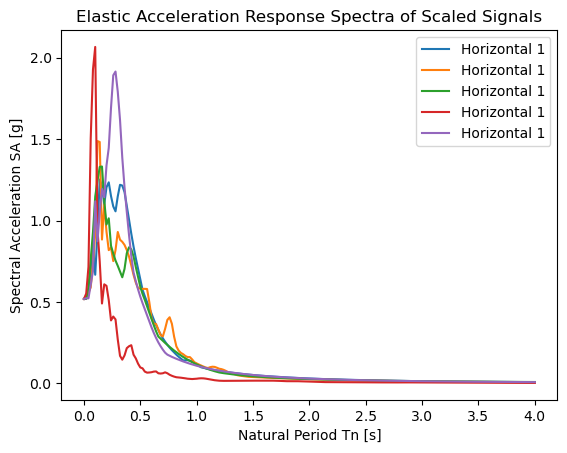

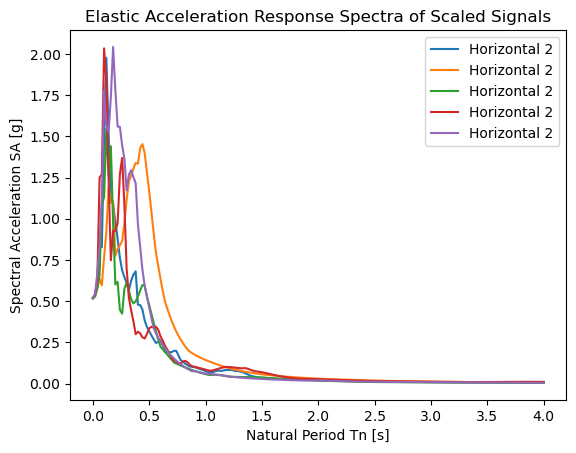

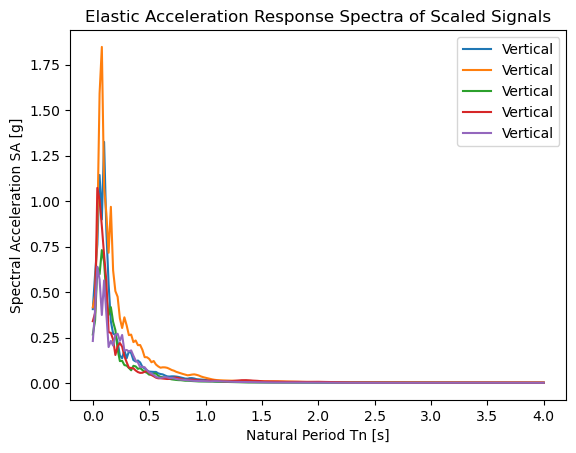

In [3]:
plt.figure()
plt.plot(Tn, SA_el_hor[:,0::2], label='Horizontal 1')
plt.xlabel('Natural Period Tn [s]')
plt.ylabel('Spectral Acceleration SA [g]')
plt.legend()
plt.title('Elastic Acceleration Response Spectra of Scaled Signals')

plt.figure()
plt.plot(Tn, SA_el_hor[:,1::2], label='Horizontal 2')
plt.xlabel('Natural Period Tn [s]')
plt.ylabel('Spectral Acceleration SA [g]')
plt.legend()
plt.title('Elastic Acceleration Response Spectra of Scaled Signals')

plt.figure()
plt.plot(Tn, SA_el_ver, label='Vertical')
plt.xlabel('Natural Period Tn [s]')
plt.ylabel('Spectral Acceleration SA [g]')
plt.legend()
plt.title('Elastic Acceleration Response Spectra of Scaled Signals')

Text(0.5, 1.0, 'Elastic Acceleration Response Spectra of Scaled Signals')

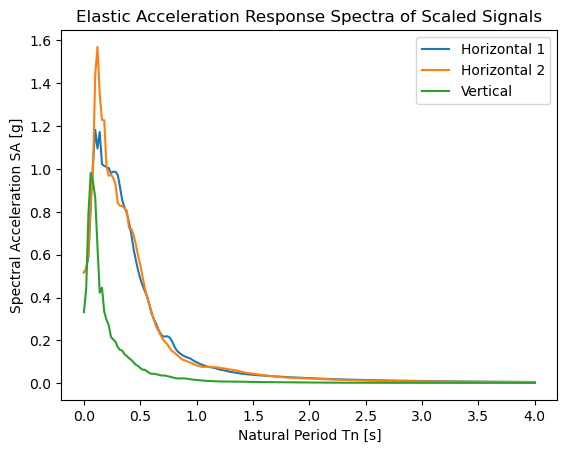

In [4]:
plt.figure()
plt.plot(Tn, SA_el_hor1_mean, label='Horizontal 1')
plt.plot(Tn, SA_el_hor2_mean, label='Horizontal 2')
plt.plot(Tn, SA_el_ver_mean, label='Vertical')
plt.xlabel('Natural Period Tn [s]')
plt.ylabel('Spectral Acceleration SA [g]')
plt.legend()
plt.title('Elastic Acceleration Response Spectra of Scaled Signals')

Explain differences with ERS from Eurocode.

--------------------------------------------------
CRITICAL EXCITATION SEARCH RESULTS:
Target Period for X-direction: Tx = 0.066 s
Target Period for Y-direction: Ty = 0.21 s
--> The most critical excitation is Set 4
--> Align Horizontal 1 to X-axis, Horizontal 2 to Y-axis
--> Resulting SA at Tx = 1.504 g
--> Resulting SA at Ty = 0.925 g
--> Total Combined SA Demand = 2.429 g
--------------------------------------------------


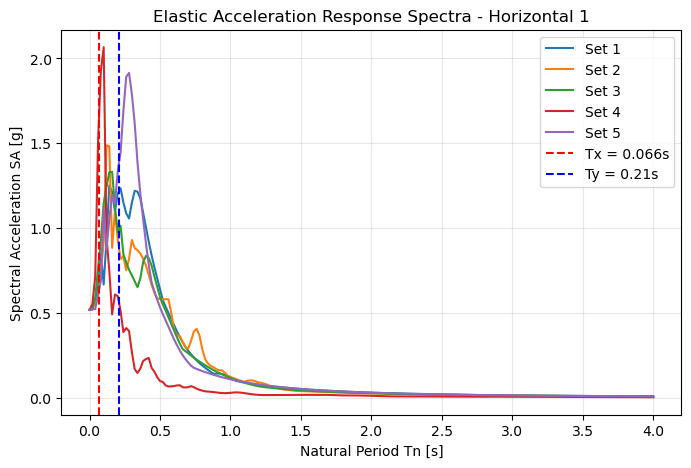

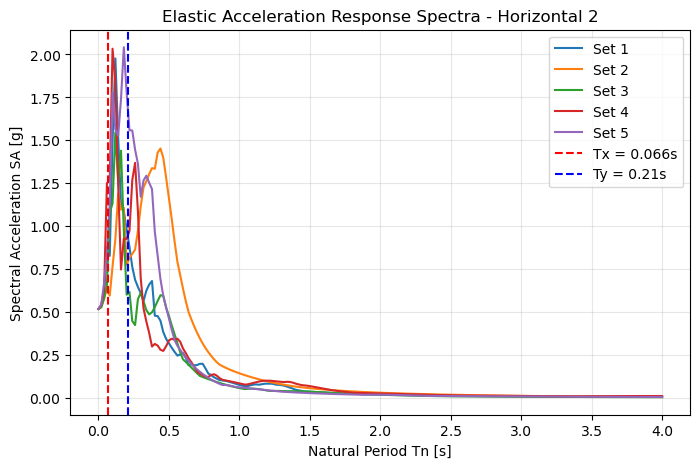

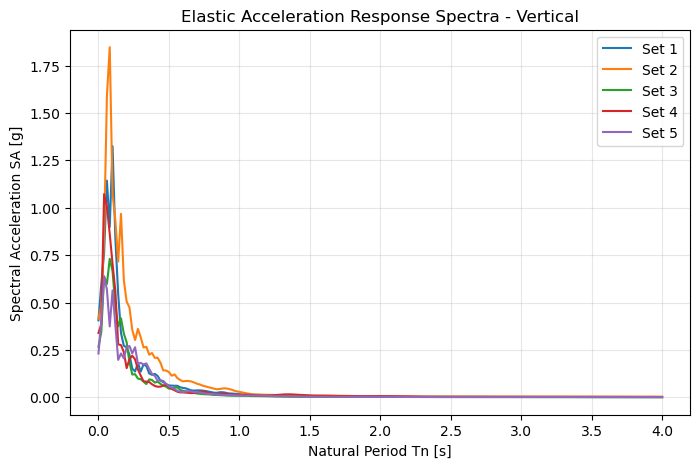

In [6]:
# --- ADD THIS BEFORE YOUR PLOTTING SECTION ---

# Define the fundamental periods of the structure
Tx = 0.066  # Stiff axis (Mode 4, X-direction)
Ty = 0.21   # Flexible axis (Mode 1, Y-direction)

# Find the closest indices in the Tn array for these periods
idx_x = np.argmin(np.abs(Tn - Tx))
idx_y = np.argmin(np.abs(Tn - Ty))

# Initialize variables to search for the critical bi-directional excitation
max_combined_sa = 0.0
critical_set = -1
critical_alignment = ""
critical_sa_x = 0.0
critical_sa_y = 0.0

# Loop through the 5 chosen sets to evaluate both possible alignments
for i in range(N): # Assuming N=5 is defined earlier in your script
    # Get SA values for both horizontal components at both structural periods
    sa_hor1_tx = SA_el_hor[idx_x, 2*i]     
    sa_hor2_tx = SA_el_hor[idx_x, 2*i + 1] 
    
    sa_hor1_ty = SA_el_hor[idx_y, 2*i]     
    sa_hor2_ty = SA_el_hor[idx_y, 2*i + 1] 
    
    # --- Alignment Case 1: Horizontal 1 -> X-axis, Horizontal 2 -> Y-axis ---
    # We use the sum of SA as a proxy for total combined base shear demand
    combined_sa_case1 = sa_hor1_tx + sa_hor2_ty
    
    if combined_sa_case1 > max_combined_sa:
        max_combined_sa = combined_sa_case1
        critical_set = i + 1
        critical_alignment = "Align Horizontal 1 to X-axis, Horizontal 2 to Y-axis"
        critical_sa_x = sa_hor1_tx
        critical_sa_y = sa_hor2_ty
        
    # --- Alignment Case 2: Horizontal 2 -> X-axis, Horizontal 1 -> Y-axis ---
    combined_sa_case2 = sa_hor2_tx + sa_hor1_ty
    
    if combined_sa_case2 > max_combined_sa:
        max_combined_sa = combined_sa_case2
        critical_set = i + 1
        critical_alignment = "Align Horizontal 2 to X-axis, Horizontal 1 to Y-axis"
        critical_sa_x = sa_hor2_tx
        critical_sa_y = sa_hor1_ty

print("-" * 50)
print(f"CRITICAL EXCITATION SEARCH RESULTS:")
print(f"Target Period for X-direction: Tx = {Tx} s")
print(f"Target Period for Y-direction: Ty = {Ty} s")
print(f"--> The most critical excitation is Set {critical_set}")
print(f"--> {critical_alignment}")
print(f"--> Resulting SA at Tx = {critical_sa_x:.3f} g")
print(f"--> Resulting SA at Ty = {critical_sa_y:.3f} g")
print(f"--> Total Combined SA Demand = {max_combined_sa:.3f} g")
print("-" * 50)


# --- MODIFIED PLOTTING SECTION ---

# Plot Horizontal 1
plt.figure(figsize=(8, 5))
plt.plot(Tn, SA_el_hor[:,0::2])
plt.axvline(x=Tx, color='r', linestyle='--', label=f'Tx = {Tx}s (X-dir)')
plt.axvline(x=Ty, color='b', linestyle='--', label=f'Ty = {Ty}s (Y-dir)')
plt.xlabel('Natural Period Tn [s]')
plt.ylabel('Spectral Acceleration SA [g]')
plt.legend(['Set 1', 'Set 2', 'Set 3', 'Set 4', 'Set 5', f'Tx = {Tx}s', f'Ty = {Ty}s'])
plt.title('Elastic Acceleration Response Spectra - Horizontal 1')
plt.grid(True, alpha=0.3)

# Plot Horizontal 2
plt.figure(figsize=(8, 5))
plt.plot(Tn, SA_el_hor[:,1::2])
plt.axvline(x=Tx, color='r', linestyle='--', label=f'Tx = {Tx}s (X-dir)')
plt.axvline(x=Ty, color='b', linestyle='--', label=f'Ty = {Ty}s (Y-dir)')
plt.xlabel('Natural Period Tn [s]')
plt.ylabel('Spectral Acceleration SA [g]')
plt.legend(['Set 1', 'Set 2', 'Set 3', 'Set 4', 'Set 5', f'Tx = {Tx}s', f'Ty = {Ty}s'])
plt.title('Elastic Acceleration Response Spectra - Horizontal 2')
plt.grid(True, alpha=0.3)

# Plot Vertical
plt.figure(figsize=(8, 5))
plt.plot(Tn, SA_el_ver)
plt.xlabel('Natural Period Tn [s]')
plt.ylabel('Spectral Acceleration SA [g]')
plt.legend(['Set 1', 'Set 2', 'Set 3', 'Set 4', 'Set 5'])
plt.title('Elastic Acceleration Response Spectra - Vertical')
plt.grid(True, alpha=0.3)

plt.show()